In [1]:
"""
fb_tools — modules walkthrough

A simple, end-to-end example of the fb_tools workflow:

    AOI -> fuelscape (LANDFIRE/LFPS) -> fuel treatment -> weather scenarios (RTMA)
        -> fire behavior (FlamMap) -> Suppression Difficulty Index (SDI)

Each section exercises one part of the package.  Data prep and weather
processing run on this Mac; the FlamMap executable itself runs on the
Windows VM (the run_batch cell is illustrative here -- see the note).
"""

import os
import json
import geopandas as gpd
import pandas as pd
from pathlib import Path

# project root (two levels up from code/notebooks/)
projdir = Path.cwd().parents[1]
proj_crs = 26913  # NAD83 UTM Zone 13N
print(f"Project directory: {projdir}")
print("Ready to go!")

Project directory: \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper
Ready to go!


## 1. Area of interest & pyrome

Load the test AOI and resolve which **pyrome** it falls in. The pyrome drives the weather-scenario lookup in section 4.

AOI pyrome: 46


<Axes: >

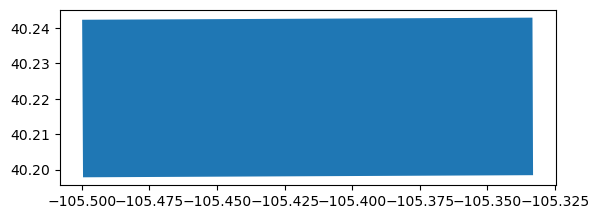

In [2]:
from fb_tools import get_pyrome_id

# --- Load a test AOI (Button Rock, CO Front Range)
aoi = gpd.read_file(projdir / "data/spatial/raw/test_aois.gpkg", layer="button_rock")

# --- Resolve the pyrome (drives the weather scenario lookup below)
pyromes_fp = projdir / "data/spatial/raw/boundaries/CO_Pyromes.gpkg"
pyrome_id = get_pyrome_id(aoi, pyromes_fp, pyrome_col="PYROME")
print(f"AOI pyrome: {pyrome_id}")

aoi.plot()

## 2. Fuelscape — LANDFIRE via LFPS

Download a baseline landscape (`.lcp`) for the AOI through the LANDFIRE Product Service (LFPS) REST API.

\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\fuelscapes\baseline\lcp_baseline.tif


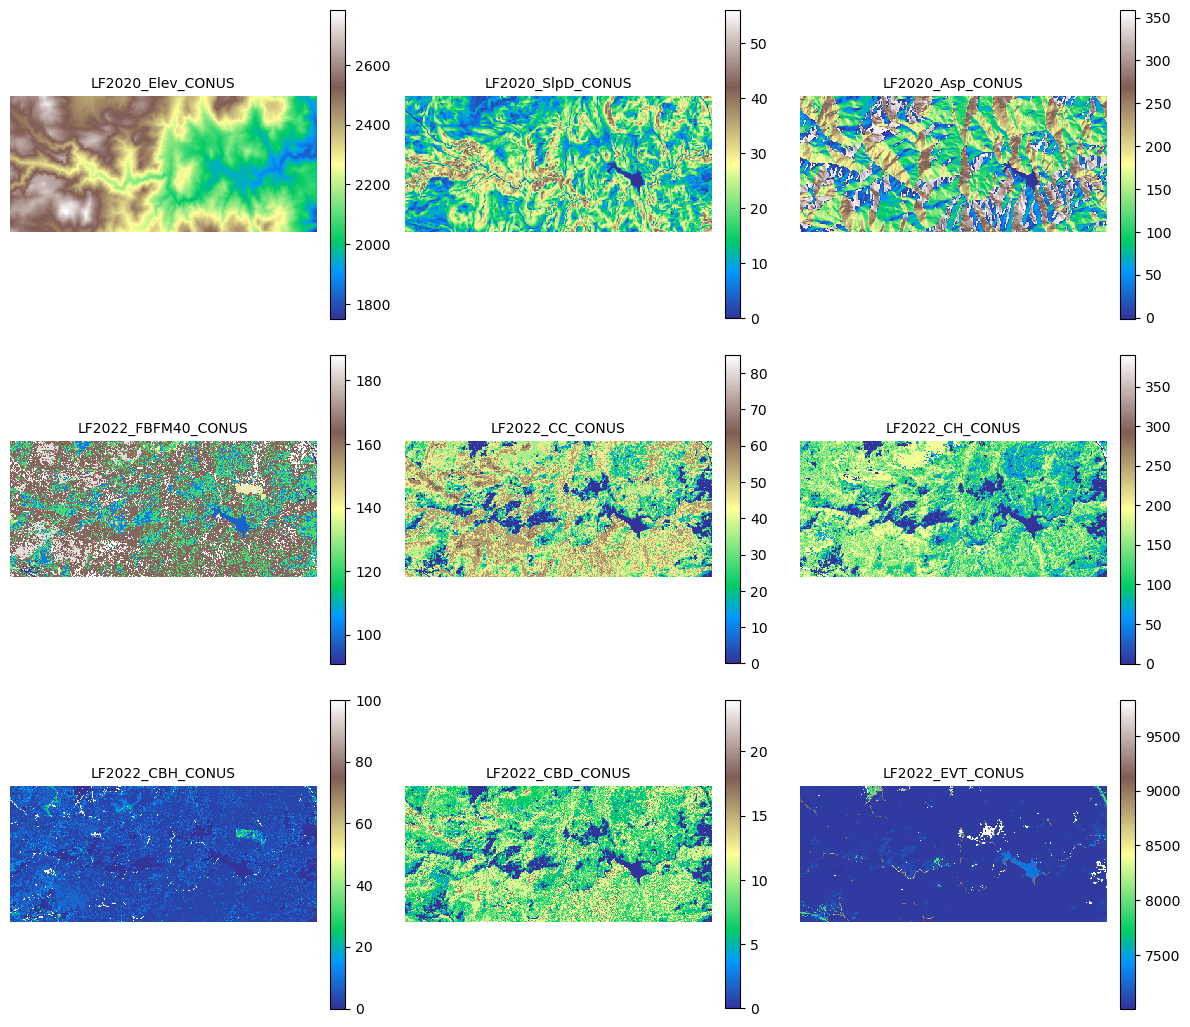

In [3]:
from fb_tools import lfps_request, plot_bands

# --- Download a baseline landscape (LCP) from LANDFIRE via the LFPS API
out_dir = projdir / "data/spatial/mod/fuelscapes/baseline"
rename  = "lcp_baseline"
runit   = False  # set True to re-download

lcp_path = out_dir / f"{rename}.tif"
if runit or not lcp_path.exists():
    lcp_da = lfps_request(
        region=aoi,
        out_dir=str(out_dir),
        lf_year="2022",
        lodgepole_adjust=True,
        rename=rename,
    )
else:
    lcp_da = str(lcp_path)
print(lcp_da)

fig, axes = plot_bands(lcp_da)

## 3. Fuel treatment

Apply a fuel modification to the landscape. Here we simulate a **moderate-severity wildfire** effect (`ModSevWF`) using the canopy/surface effect lookup tables, then save the treated LCP.

In [4]:
from fb_tools import apply_treatment

# --- Fuel-modification lookup tables (canopy + surface effects by treatment)
canopy  = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/canopy_effects.csv")
surface = pd.read_csv(projdir / "data/tabular/raw/fuel_mods/surface_effects.csv")
print(f"Treatments: {list(canopy.Treatment.unique())}")

# --- Apply a moderate-severity wildfire effect to every pixel
treated = apply_treatment(
    lcp=lcp_da,
    canopy_df=canopy,
    surface_df=surface,
    scenario={"canopy": "ModSevWF", "surface": "ModSevWF"},
)

# --- Save the treated landscape
trt_fp = projdir / "data/spatial/mod/fuelscapes/treated/lcp_ModSevWF.tif"
trt_fp.parent.mkdir(parents=True, exist_ok=True)
treated.rio.to_raster(trt_fp)
print(f"Saved -> {trt_fp}")

Treatments: ['Thin', 'Hand Thin', 'Mech Thin', 'RxFire', 'Complete Hand', 'Complete Mech', 'Masticate', 'Patch', 'LowSevWF', 'ModSevWF', 'HighSevWF', 'Overstory']
Saved -> \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\fuelscapes\treated\lcp_ModSevWF.tif


## 4. Weather scenarios — RTMA fuel moisture + HRRR winds

Build per-pyrome FlamMap weather / fuel-moisture scenarios at ERC percentiles
(`p25` … `p97`). Fuel moisture comes from **RTMA** (NWS Real-Time Mesoscale
Analysis); the ERC percentile *bands* that define each scenario's representative
days are still GridMET-driven, and peak-hour wind speeds come from the HRRR
wind-cell cache. The full RTMA build (hourly NFDRS78 time-lag) lives in
`00b_RTMA-FM.ipynb`; here we load its cached daily output to keep things quick.

In [5]:
from fb_tools import (
    load_gridmet_csv,
    wind_percentiles_from_cell_cache,
    build_flammap_scenario_cache,
    load_flammap_scenario_cache,
)

CACHE_DIR = projdir / "data/weather/flammap_rtma"

# --- ERC climatology (defines the percentile day-bands)
gridmet = load_gridmet_csv(projdir / "data/tabular/raw/weather/gridmet_clim_CO_pyromes.csv")

# --- Peak-hour wind speed percentiles from the HRRR wind-cell cache
wind_pcts = wind_percentiles_from_cell_cache(projdir / "data/weather/pyrome_wind")

# --- RTMA daily peak-hour fuel moisture (pre-computed; see 00b_RTMA-FM.ipynb)
#     Full build: load_rtma_csv -> build_rtma_dead_fm -> collapse_to_peak_hour
#                 -> build_rtma_live_fm -> merge.  Cached here to skip the
#                 (expensive) hourly NFDRS78 time-lag.
rtma_daily = pd.read_parquet(CACHE_DIR / "rtma_daily_fm.parquet")
print(f"RTMA daily frame: {rtma_daily.shape}")

  [load_gridmet_csv] 30,816 rows, 9 pyromes, years 2010–2025  [legacy flat]
  [wind_percentiles_from_cell_cache] 9 pyromes × 5 percentiles
RTMA daily frame: (28467, 12)


In [6]:
# --- Build the per-pyrome scenario cache (RTMA FM sources). Cached as
#     pyrome_{id}_flammap.json; set runit=True to rebuild.
runit = False
if runit or not (CACHE_DIR / f"pyrome_{pyrome_id}_flammap.json").exists():
    build_flammap_scenario_cache(
        gridmet,
        pyrome_col="pyrome",
        lat_deg=39.5,             # representative CO latitude (GSI live FM)
        wind_direction=-2,        # FlamMap downhill convention
        wind_percentiles=wind_pcts,
        dead_fm_source="rtma",
        live_fm_source="rtma",
        rtma_daily_df=rtma_daily,
        rtma_pyrome_col="pyrome_id",
        rtma_date_col="date",
        out_dir=CACHE_DIR,
    )

# --- Load the scenarios for our AOI's pyrome
fm_params = load_flammap_scenario_cache(pyrome_id, CACHE_DIR)
pd.DataFrame(fm_params["scenarios"]).T[
    ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody", "WIND_SPEED", "erc_center"]
]

,FM_1hr,FM_10hr,FM_100hr,FM_herb,FM_woody,WIND_SPEED,erc_center
p25,8.5,13.8,15.1,132.4,125.2,8.1,38.0
p50,6.5,10.4,13.2,89.1,97.6,12.3,48.0
p75,5.1,8.9,11.2,61.5,80.0,17.0,58.8
p90,4.5,7.4,10.1,49.3,72.3,21.5,67.0
p97,3.8,6.0,7.9,30.0,60.0,27.0,74.0


## 5. Build the FlamMap scenario table

Turn the loaded scenario cache into a `conditions` table (one row per ERC percentile), then take the cross-product with the LCPs (baseline + treated) to get one row per model run.

In [7]:
from fb_tools import build_scenarios, list_files

# --- Turn the loaded cache into a build_scenarios "conditions" table
#     (one row per ERC percentile).
keep = ["FM_1hr", "FM_10hr", "FM_100hr", "FM_herb", "FM_woody",
        "WIND_SPEED", "WIND_DIRECTION"]
conditions = pd.DataFrame([
    {"Scenario": pct, **{k: s[k] for k in keep}}
    for pct, s in fm_params["scenarios"].items()
])
print(conditions)

# --- LCPs to pair with every scenario (baseline + treated)
lcp_dir = projdir / "data/spatial/mod/fuelscapes"
lcps = list_files(lcp_dir, "*.tif", recursive=True)
print(f"\nLCPs: {[Path(p).name for p in lcps]}")

# --- Cross-product: (n percentiles x n LCPs) runs
scenarios_df = build_scenarios(
    conditions, lcps,
    outputs="FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",
)
print(f"\n{len(scenarios_df)} total runs")
scenarios_df.head()

  Scenario  FM_1hr  FM_10hr  FM_100hr  FM_herb  FM_woody  WIND_SPEED  \
0      p25     8.5     13.8      15.1    132.4     125.2         8.1   
1      p50     6.5     10.4      13.2     89.1      97.6        12.3   
2      p75     5.1      8.9      11.2     61.5      80.0        17.0   
3      p90     4.5      7.4      10.1     49.3      72.3        21.5   
4      p97     3.8      6.0       7.9     30.0      60.0        27.0   

   WIND_DIRECTION  
0              -2  
1              -2  
2              -2  
3              -2  
4              -2  

LCPs: ['lcp_baseline.tif', 'lcp_ModSevWF.tif']

10 total runs


,Scenario,LCP,FM_1hr,FM_10hr,FM_100hr,FM_herb,FM_woody,WIND_SPEED,WIND_DIRECTION,CROWN_FIRE_METHOD,GRIDDED_WINDS_GENERATE,GRIDDED_WINDS_RESOLUTION,Outputs,FM_1000hr,ERC,FM_NAME
0,p25,\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...,8.5,13.8,15.1,132.4,125.2,8.1,-2,ScottReinhardt,No,30,"FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",None,None,lcp_baseline
1,p50,\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...,6.5,10.4,13.2,89.1,97.6,12.3,-2,ScottReinhardt,No,30,"FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",None,None,lcp_baseline
2,p75,\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...,5.1,8.9,11.2,61.5,80.0,17.0,-2,ScottReinhardt,No,30,"FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",None,None,lcp_baseline
3,p90,\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...,4.5,7.4,10.1,49.3,72.3,21.5,-2,ScottReinhardt,No,30,"FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",None,None,lcp_baseline
4,p97,\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fi...,3.8,6.0,7.9,30.0,60.0,27.0,-2,ScottReinhardt,No,30,"FLAMELENGTH, CROWNSTATE, SPREADRATE, HEATAREA",None,None,lcp_baseline


In [8]:
# # --- Alternative: load a hand-built scenario table from CSV instead
# from fb_tools import load_scenarios
# scenarios_df = load_scenarios(
#     projdir / "code/dev/inputs/FlamMap/fire_scenarios.csv",
#     lcp_dir=lcp_dir,   # resolves bare filenames to full paths
# )

## 6. Run FlamMap (batch)

> **Note:** the FlamMap executable (`TestFlamMap.exe`) runs on the **Windows VM**. On this Mac the cell below detects the missing executable and skips execution — run this section on the VM to produce the output rasters consumed by the SDI step.

p25
['CROWNSTATE', 'FLAMELENGTH', 'HEATAREA', 'SPREADRATE']
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\p25\p25_LCP_BASELINE.tif
Stacked 4 rasters → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\p25\p25_LCP_BASELINE.tif
[success] lcp_baseline / p25
p50
['CROWNSTATE', 'FLAMELENGTH', 'HEATAREA', 'SPREADRATE']
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\p50\p50_LCP_BASELINE.tif
Stacked 4 rasters → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\p50\p50_LCP_BASELINE.tif
[success] lcp_baseline / p50
p75
['CROWNSTATE', 'FLAMELENGTH', 'HEATAREA', 'SPREADRATE']
\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\p75\p75_LCP_BASEL

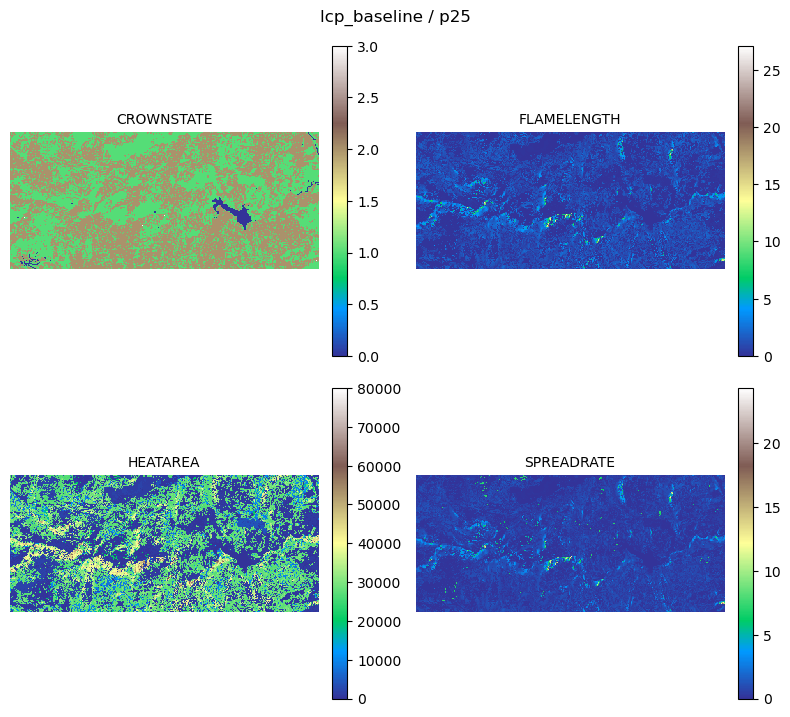

In [9]:
from fb_tools import run_batch
import rioxarray as rxr

output_root = projdir / "data/spatial/mod/flammap/outputs"

# FlamMap executable runs on the Windows VM; skip gracefully on Mac.
exe = list_files(projdir, "TestFlamMap.exe", recursive=True)
if not exe:
    print("TestFlamMap.exe not found -- run this section on the Windows VM.")
else:
    summary = run_batch(
        fm_exe=exe[0],
        scenarios_df=scenarios_df,
        output_root=output_root,
        n_process=3,
        stack_out=True,   # stack per-output TIFFs -> one multiband file per run
        cleanup=True,     # remove the single-band TIFFs afterward
    )

    # --- Check for failures
    failures = summary[summary["status"] != "success"]
    if not failures.empty:
        print("Failed runs:")
        print(failures[["Scenario", "LCP", "status"]])

    # --- Inspect one result
    row = summary.iloc[0]
    stacked = next(Path(row["output_dir"]).glob("*.tif"))
    da = rxr.open_rasterio(stacked, masked=True)
    fig, axes = plot_bands(da, cols=2)
    fig.suptitle(f"{Path(row['LCP']).stem} / {row['Scenario']}", y=1.02)

## 7. Suppression — OSM roads & trails

Fetch road and trail features for the AOI from OpenStreetMap. These act as control features in the SDI calculation.

  Querying OSM chunk 1/1 ...
    139 raw features
OSM: 59 road segments, 124 trail segments


<Axes: >

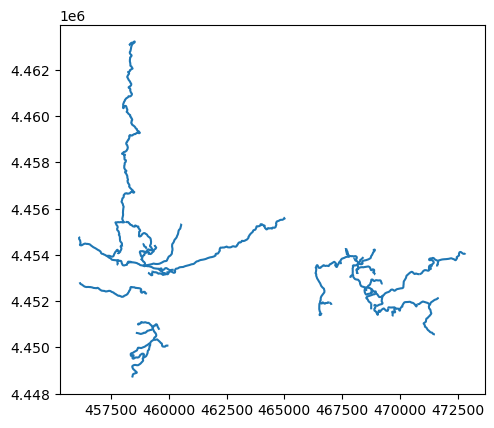

In [10]:
from fb_tools import fetch_osm_roads

roads, trails = fetch_osm_roads(aoi, out_crs=proj_crs)
roads.plot()

## 8. Suppression Difficulty Index (SDI)

Combine fire behavior (FlamMap flame length / spread), terrain, and control features into the **Suppression Difficulty Index**, then compare baseline vs. treated and map the change (`delta SDI`). Uses the 97th-percentile (`p97`) FlamMap output.

In [11]:
from fb_tools import calculate_sdi, calculate_delta_sdi, stacked_output_path

# --- Locate the p97 FlamMap output for the baseline LCP
#     (produced by the run_batch step on the Windows VM)
fm_stack = stacked_output_path(output_root, lcp_path, scenario="p97")
print(fm_stack)

rtc_fp  = projdir / "code/dev/SDI/08_RTC_lookup_SDIwt_westernUS_2021_update.txt"
sdi_dir = projdir / "data/spatial/mod/sdi"
sdi_dir.mkdir(parents=True, exist_ok=True)

# --- Baseline SDI
sdi_base = calculate_sdi(
    lcp=lcp_da, flammap_stack=fm_stack,
    roads_gdf=roads, trails_gdf=trails,
    rtc_path=str(rtc_fp),
    out_path=str(sdi_dir / "SDI97_BASELINE.tif"),
)

# --- Treated SDI
sdi_treated = calculate_sdi(
    lcp=treated, flammap_stack=fm_stack,
    roads_gdf=roads, trails_gdf=trails,
    rtc_path=str(rtc_fp),
    out_path=str(sdi_dir / "SDI97_MODSEVWF.tif"),
)

# --- Change in suppression difficulty (treated - baseline)
delta_sdi = calculate_delta_sdi(
    sdi_base, sdi_treated,
    out_path=str(sdi_dir / "deltaSDI97_ModSevWF.tif"),
)

\\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\flammap\outputs\lcp_baseline\p97\p97_LCP_BASELINE.tif
Computing road distance...
Computing trail density...
Computing sub-indices...
Assembling final SDI...
SDI saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\sdi\SDI97_BASELINE.tif
Computing road distance...
Computing trail density...
Computing sub-indices...
Assembling final SDI...
SDI saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\sdi\SDI97_MODSEVWF.tif
Delta SDI saved → \\Mac\Home\Library\CloudStorage\Box-Box\MCC\fire_modeling\FM_PythonWrapper\data\spatial\mod\sdi\deltaSDI97_ModSevWF.tif
